In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


# Import libraries 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import math

from sklearn.preprocessing import StandardScaler, OneHotEncoder ,OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn import set_config
set_config(transform_output='pandas')

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')


# Load and inspect data

In [3]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


# EDA

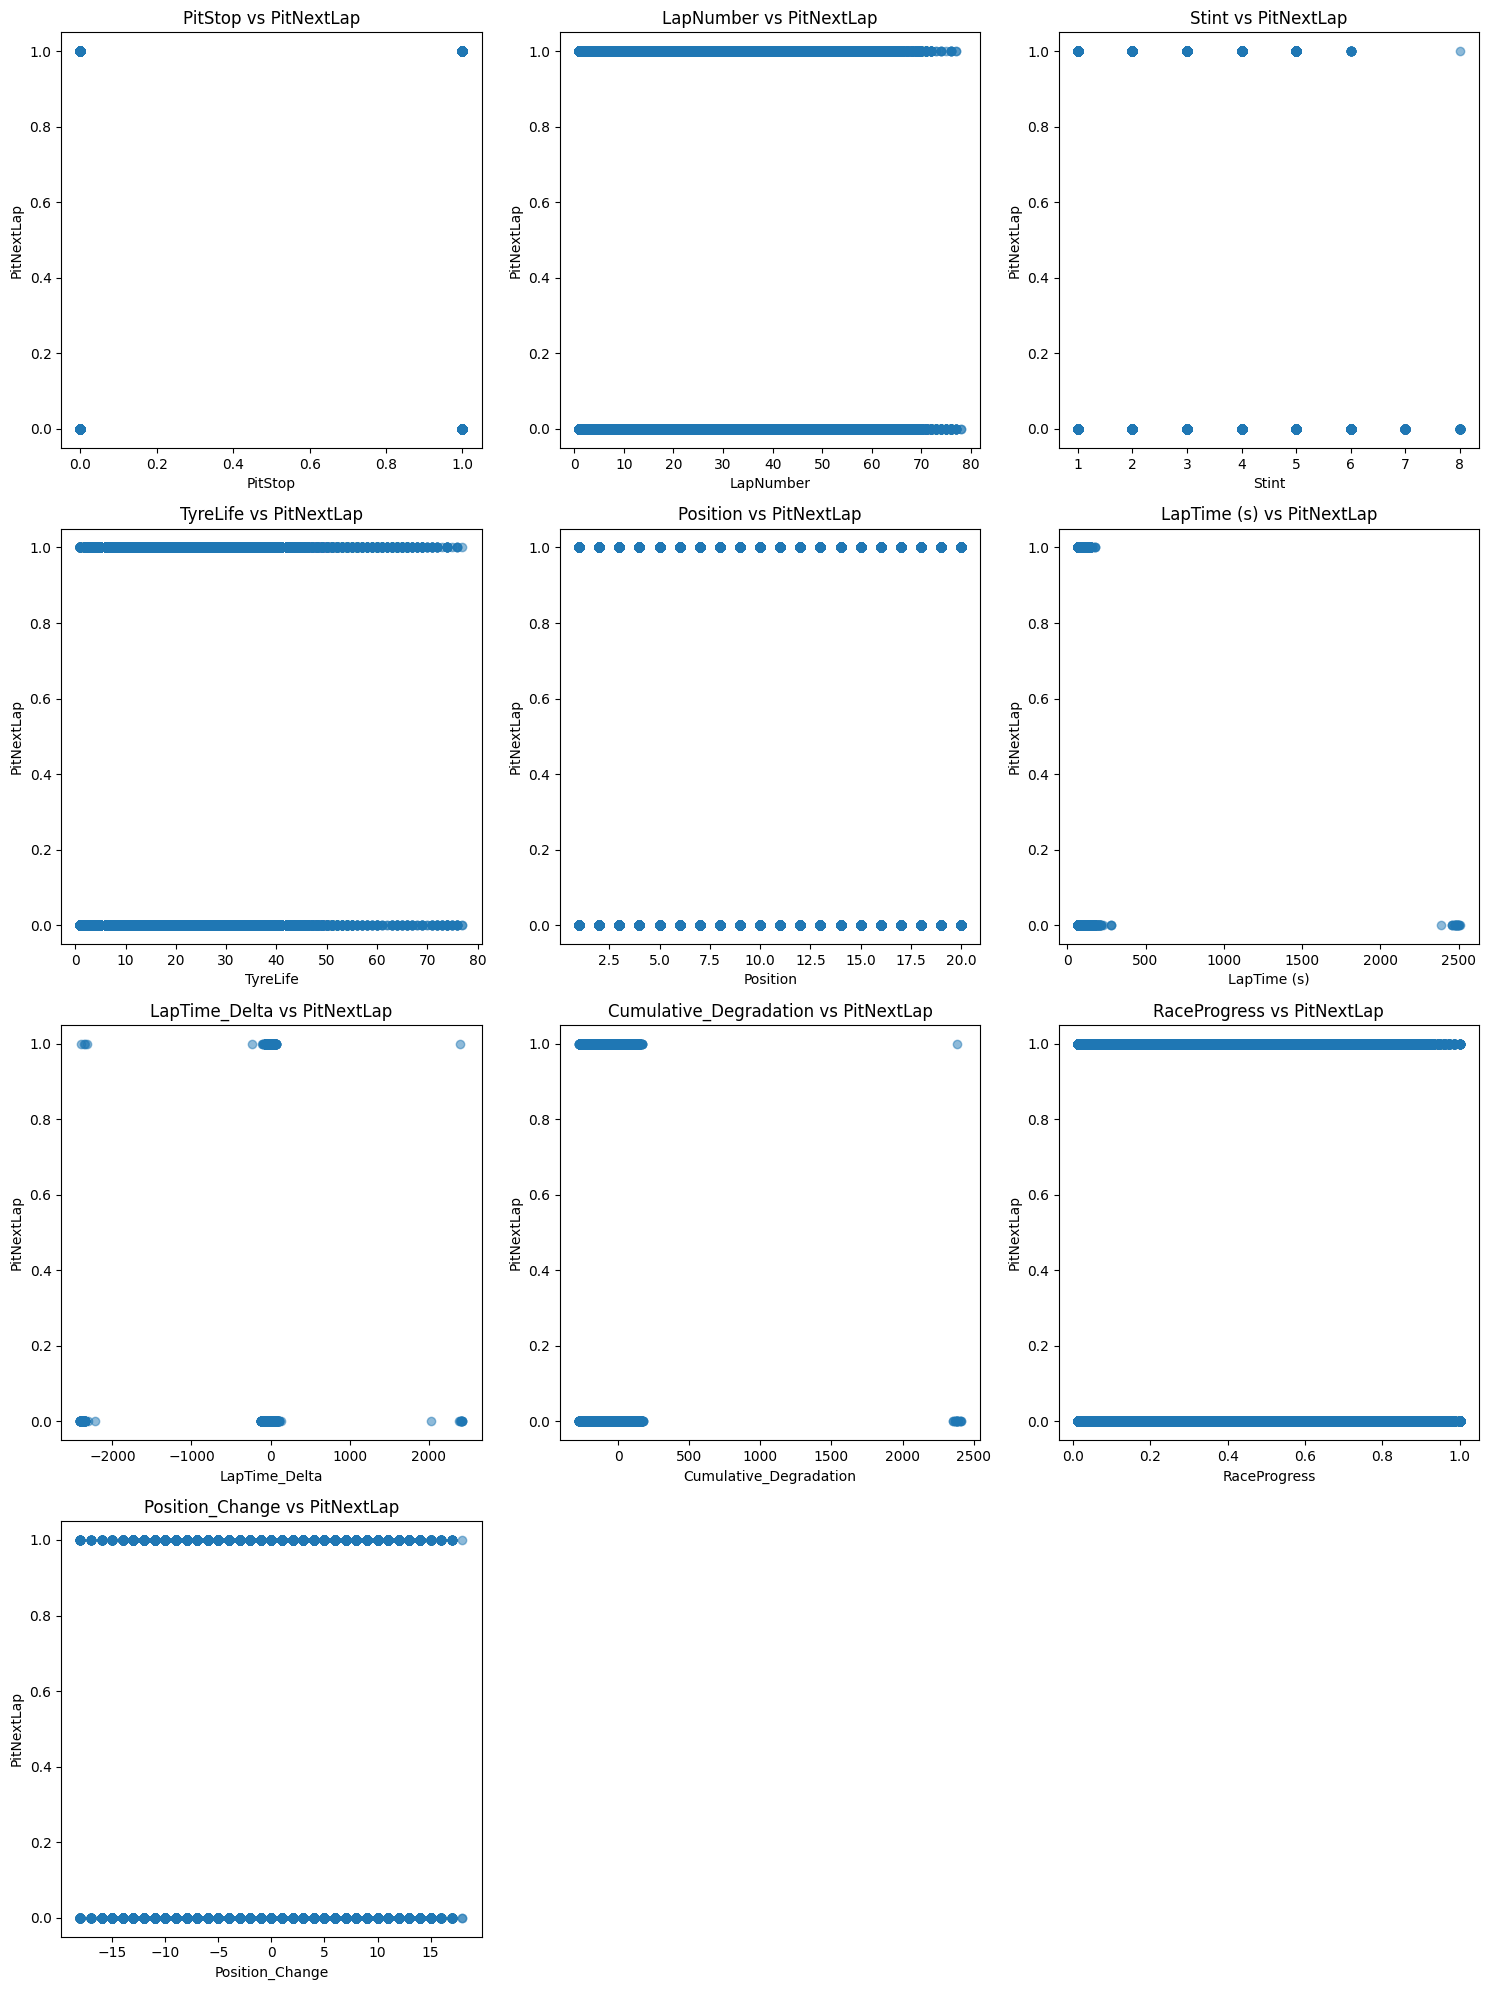

In [13]:


# Features and target
features = [
    "PitStop", "LapNumber", "Stint", "TyreLife", "Position",
    "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
    "RaceProgress", "Position_Change"
]

target = "PitNextLap"

# Calculate grid size
n = len(features)
cols = 3  # number of columns in subplot grid
rows = math.ceil(n / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Plot each feature vs target
for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df[target], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)
    axes[i].set_title(f"{feature} vs {target}")

# Remove extra empty plots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

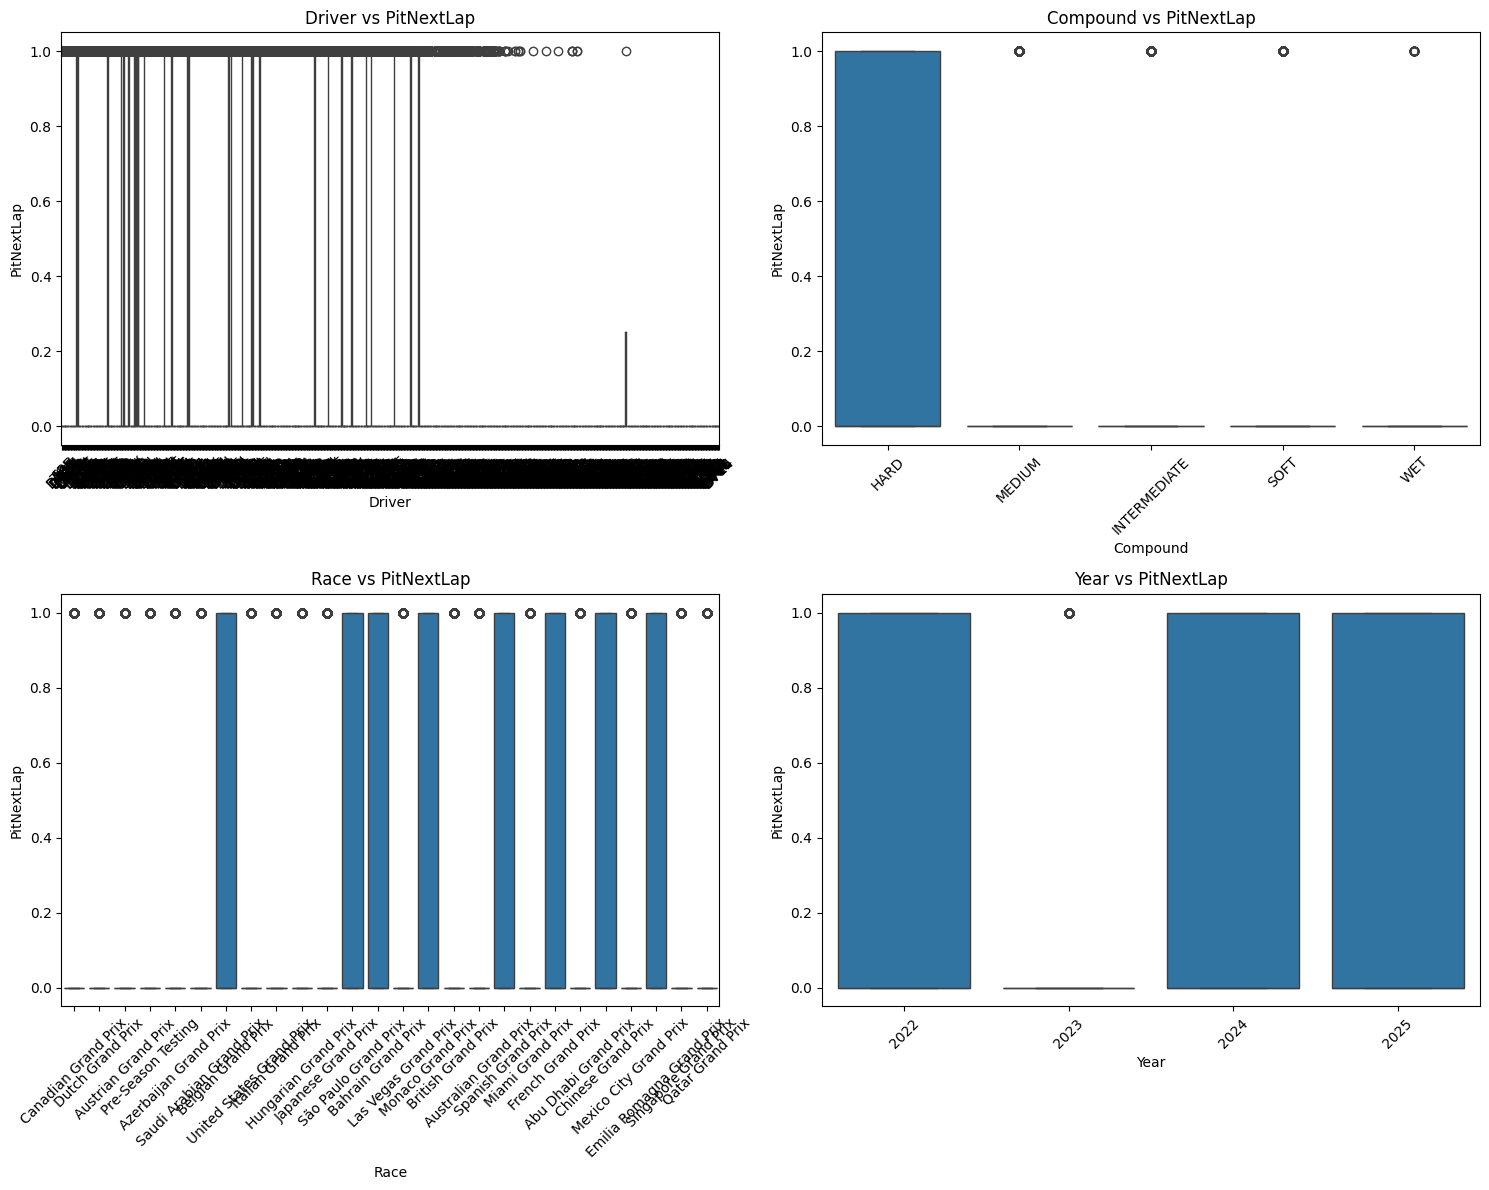

In [7]:
# Categorical features and target
features = ["Driver", "Compound", "Race", "Year"]
target = "PitNextLap"

# Grid layout
n = len(features)
cols = 2
rows = math.ceil(n / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten()

# Plot boxplots
for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], y=df[target], ax=axes[i])
    axes[i].set_title(f"{feature} vs {target}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Preprocessing

## Feature Engineering

In [14]:
def engineer_features(df):
    import numpy as np
    
    df = df.copy()

    # ✅ 1. Sort for time consistency
    df = df.sort_values(["Driver", "Race", "Year", "LapNumber"])

    # ✅ 2. Race Progress
    max_lap = df.groupby(["Race", "Year"])["LapNumber"].transform("max")
    df["RaceProgress"] = df["LapNumber"] / max_lap

    # ✅ 3. Tire Degradation (stable)
    df["Deg_per_Lap"] = df["Cumulative_Degradation"] / (df["TyreLife"] + 1)
    df["Deg_Rolling"] = df.groupby(["Driver","Race","Year"])["Deg_per_Lap"]\
                           .transform(lambda x: x.rolling(5, min_periods=1).mean())

    # ✅ 4. Rolling Lap Time (IMPORTANT)
    df["LapTime_RollMean_3"] = df.groupby(["Driver","Race","Year"])["LapTime (s)"]\
                                .transform(lambda x: x.rolling(3, min_periods=1).mean())

    df["LapTime_RollMean_5"] = df.groupby(["Driver","Race","Year"])["LapTime (s)"]\
                                .transform(lambda x: x.rolling(5, min_periods=1).mean())

    df["LapTime_RollStd_5"] = df.groupby(["Driver","Race","Year"])["LapTime (s)"]\
                               .transform(lambda x: x.rolling(5, min_periods=2).std())

    # ✅ 5. Lag Features
    df["Lag1"] = df.groupby(["Driver","Race","Year"])["LapTime (s)"].shift(1)
    df["Lag3"] = df.groupby(["Driver","Race","Year"])["LapTime (s)"].shift(3)

    # ✅ 6. Lap Dynamics
    df["LapTime_Change"] = df.groupby(["Driver","Race","Year"])["LapTime (s)"].diff()
    df["Sudden_Drop"] = (df["LapTime_Change"] > 1.2).astype(int)

    # ✅ 7. Relative Pace
    race_avg = df.groupby(["Race","Year","LapNumber"])["LapTime (s)"].transform("mean")
    df["Rel_Pace"] = df["LapTime (s)"] - race_avg
    df["Rel_Pace_Scaled"] = df["Rel_Pace"] / (race_avg + 1e-5)

    # ✅ 8. Driver Consistency
    grp = df.groupby(["Driver","Race","Year"])["LapTime (s)"]
    df["Driver_Mean"] = grp.transform("mean")
    df["Driver_Std"] = grp.transform("std")
    df["Consistency_Index"] = df["Driver_Std"] / (df["Driver_Mean"] + 1e-5)

    # ✅ 9. Stint Features
    stint_len = df.groupby(["Driver","Race","Year","Stint"])["LapNumber"].transform("count")
    df["Stint_Length"] = stint_len
    df["Stint_Progress"] = df["TyreLife"] / (stint_len + 1)
    df["Tyre_Used_Ratio"] = df["TyreLife"] / (stint_len + 1)
    df["Is_New_Tyre"] = (df["TyreLife"] <= 2).astype(int)

    # ✅ 10. Pit Awareness
    df["Laps_Since_Pit"] = df.groupby(["Driver","Race","Year"])["PitStop"].cumsum()
    df["Just_Pitted"] = df.groupby(["Driver","Race","Year"])["PitStop"].shift(1).fillna(0)

    # ✅ 11. Position Features
    df["Position_Trend"] = df.groupby(["Driver","Race","Year"])["Position"].diff()
    df["Is_Gaining"] = (df["Position_Trend"] < 0).astype(int)
    df["Top3"] = (df["Position"] <= 3).astype(int)

    # ✅ 12. Compound-derived signals (NO encoding here!)
    # Only domain-based signals, no numeric mapping

    df["Is_Wet"] = df["Compound"].isin(["WET", "INTERMEDIATE"]).astype(int)
    df["Is_Slick"] = df["Compound"].isin(["SOFT", "MEDIUM", "HARD"]).astype(int)

    # simple grip tiers (optional but useful)
    df["High_Grip"] = (df["Compound"] == "SOFT").astype(int)
    df["Low_Grip"] = (df["Compound"].isin(["HARD", "WET"])).astype(int)

    # ✅ 13. Interaction Features (safe ones)
    df["TyreLife_x_Degradation"] = df["TyreLife"] * df["Cumulative_Degradation"]
    df["RelPace_x_TyreLife"] = df["Rel_Pace"] * df["TyreLife"]
    df["Position_x_RaceProgress"] = df["Position"] * df["RaceProgress"]

    # ✅ 14. Cleaning
    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)

    return df

In [15]:
df = engineer_features(df)

## define X and y

In [16]:
# Create the input feature matrix
X = df.drop(["PitNextLap", "id"], axis=1)

# Create the target vector
y = df ["PitNextLap"]

## split data

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:


# Ordinal feature
ordinal_feature = ["Compound"]
compound_order = [["WET", "INTERMEDIATE", "SOFT", "MEDIUM", "HARD"]]

ordinal_encoder = OrdinalEncoder(categories=compound_order)

# Categorical features
cat_selector = ["Driver", "Race", "Year"]
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Numeric features
num_cols = X_train.select_dtypes("number").columns
scaler = StandardScaler()

# ----------- COLUMN TRANSFORMER -----------

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_encoder, ordinal_feature),
        ('categorical', ohe, cat_selector),
        ('numeric', scaler, num_cols)
    ]
)



## COLUMN TRANSFORMER

In [19]:
preprocessor.fit(X_train)
x_train_transformed=preprocessor.transform(X_train)
x_test_transformed=preprocessor.transform(X_test)

# Build LightGBM model

In [14]:


model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=64,
    max_depth=10,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42,
    class_weight='balanced'
)


model.fit(
    x_train_transformed, y_train,
    eval_metric='auc'
)



y_pred_proba = model.predict_proba(x_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC Score: {auc:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69939, number of negative: 281373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7198
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 660
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
AUC Score: 0.9458


## Test data

In [15]:
df2=pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
df2 = engineer_features(df2)
new_x = preprocessor.transform(df2)

In [16]:
pred_probs = model.predict(new_x) 
pred = (pred_probs >= 0.5).astype(int)



tensorflow = pd.DataFrame({
    'id': df2['id'].values,
    'PitNextLap':pred.ravel()
})



tensorflow.to_csv('/kaggle/working/sample_submission.csv', index=False)


In [17]:
df3=pd.read_csv('/kaggle/working/sample_submission.csv')
df3['PitNextLap'].value_counts()

PitNextLap
0    131334
1     56831
Name: count, dtype: int64

# Tunning LightGBM model

In [18]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [25]:
import optuna
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 4, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "class_weight": "balanced"
    }

    model = LGBMClassifier(**params)


    model.fit(x_train_transformed, y_train)

    y_pred_proba = model.predict_proba(x_test_transformed)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)

    return auc


In [26]:
import optuna

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)
print("Best AUC:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-18 06:16:06,475] A new study created in memory with name: no-name-7f956f76-a05f-4612-9c62-0f85efa7a05f


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69939, number of negative: 281373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097761 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7054
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 588
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


[I 2026-05-18 06:17:15,212] Trial 0 finished with value: 0.9420363325658355 and parameters: {'n_estimators': 902, 'learning_rate': 0.007089667952069195, 'num_leaves': 62, 'max_depth': 11, 'min_child_samples': 55, 'subsample': 0.7037879555929676, 'colsample_bytree': 0.7307334165907278, 'reg_alpha': 4.944414507737466, 'reg_lambda': 4.21367547670017}. Best is trial 0 with value: 0.9420363325658355.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69939, number of negative: 281373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.096886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7082
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 602
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

[I 2026-05-18 06:18:27,816] Trial 1 finished with value: 0.9384456073538275 and parameters: {'n_estimators': 1636, 'learning_rate': 0.0072550060337094645, 'num_leaves': 44, 'max_depth': 5, 'min_child_samples': 44, 'subsample': 0.9458048557022183, 'colsample_bytree': 0.7589530239180763, 'reg_alpha': 0.9543572172037318, 'reg_lambda': 1.733503507988332}. Best is trial 0 with value: 0.9420363325658355.


...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69939, number of negative: 281373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.093708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7060
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 591
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-05-18 06:21:35,968] Trial 3 finished with value: 0.9468357472814586 and parameters: {'n_estimators': 1924, 'learning_rate': 0.03630517358692093, 'num_leaves': 79, 'max_depth': 12, 'min_child_samples': 54, 'subsample': 0.8825827481742009, 'colsample_bytree': 0.6517982785851429, 'reg_alpha': 0.5677807248959948, 'reg_lambda': 1.5073339127918184}. Best is trial 3 with value: 0.9468357472814586.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69939, number of negative: 281373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.092744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7134
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 628
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

[I 2026-05-18 06:22:35,293] Trial 4 finished with value: 0.9457171998881408 and parameters: {'n_estimators': 1004, 'learning_rate': 0.021207937627045172, 'num_leaves': 58, 'max_depth': 9, 'min_child_samples': 27, 'subsample': 0.6174660234981625, 'colsample_bytree': 0.6983294895860276, 'reg_alpha': 2.934257400943378, 'reg_lambda': 4.262260771332786}. Best is trial 3 with value: 0.9468357472814586.


Best AUC: 0.9468357472814586
Best parameters: {'n_estimators': 1924, 'learning_rate': 0.03630517358692093, 'num_leaves': 79, 'max_depth': 12, 'min_child_samples': 54, 'subsample': 0.8825827481742009, 'colsample_bytree': 0.6517982785851429, 'reg_alpha': 0.5677807248959948, 'reg_lambda': 1.5073339127918184}


In [27]:
best_params = study.best_params

final_model = LGBMClassifier(
    **best_params,
    random_state=42,
    class_weight="balanced"
)

final_model.fit(x_train_transformed, y_train)


y_pred_proba = final_model.predict_proba(x_test_transformed)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Final Test AUC: {test_auc:.4f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69939, number of negative: 281373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.096440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7060
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 591
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Final Test AUC: 0.9468


## Test data

In [28]:
red_probs = final_model.predict(new_x) 
pred = (pred_probs >= 0.5).astype(int)



tensorflow = pd.DataFrame({
    'id': df2['id'].values,
    'PitNextLap':pred.ravel()
})



tensorflow.to_csv('/kaggle/working/sample_submission2.csv', index=False)

In [29]:
df4=pd.read_csv('/kaggle/working/sample_submission2.csv')
df4['PitNextLap'].value_counts()

PitNextLap
0    131334
1     56831
Name: count, dtype: int64

# Neural Network

In [20]:
print("x_train_transformed shape:", x_train_transformed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train_transformed shape: (351312, 942)
y_train shape: (351312,)
y_test shape: (87828,)


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid

2026-05-18 06:45:18.041829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779086718.282134      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779086718.350735      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779086718.986314      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779086718.986351      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779086718.986354      57 computation_placer.cc:177] computation placer alr

In [22]:
from tensorflow.keras import regularizers
model = tf.keras.Sequential([
        tf.keras.layers.Dense(
        128, activation='relu',
        input_shape=(942,),
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(0.3), 
    tf.keras.layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(0.3),          
    tf.keras.layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

2026-05-18 06:45:49.108744: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

In [24]:
history = model.fit(
    x_train_transformed, y_train,
    epochs=40,               
    validation_data=(x_test_transformed, y_test),
    batch_size=32
)

Epoch 1/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - AUC: 0.8947 - loss: 0.3273 - val_AUC: 0.9277 - val_loss: 0.2813
Epoch 2/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 54s 5ms/step - AUC: 0.9201 - loss: 0.2918 - val_AUC: 0.9286 - val_loss: 0.2776
Epoch 3/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - AUC: 0.9214 - loss: 0.2907 - val_AUC: 0.9299 - val_loss: 0.2764
Epoch 4/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - AUC: 0.9233 - loss: 0.2872 - val_AUC: 0.9297 - val_loss: 0.2772
Epoch 5/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - AUC: 0.9237 - loss: 0.2863 - val_AUC: 0.9300 - val_loss: 0.2759
Epoch 6/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - AUC: 0.9239 - loss: 0.2860 - val_AUC: 0.9314 - val_loss: 0.2733
Epoch 7/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - AUC: 0.9245 - loss: 0.2851 - val_AUC: 0.9311 - val_loss: 0.2746
Epoch 8/40
10979/10979 ━━━━━━━━━━━━━━━━━━━━ 55s 5ms/step - AUC: 0.9248 - loss: 0.2852 - val_AUC: 0.9303 - val_loss: 0.2767
Epoch 9/40
10979

In [25]:
df2=pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
df2 = engineer_features(df2)
new_x = preprocessor.transform(df2)

pred_probs = model.predict(new_x) 
pred = (pred_probs >= 0.5).astype(int)
tensorflow = pd.DataFrame({
    'id': df2['id'].values,
    'PitNextLap':pred.ravel()
})

tensorflow.to_csv('/kaggle/working/sample_submission3.csv', index=False)
df3=pd.read_csv('/kaggle/working/sample_submission3.csv')
df3['PitNextLap'].value_counts()

5881/5881 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


PitNextLap
0    149485
1     38680
Name: count, dtype: int64